In [1]:
# Importing required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import seaborn as sns
import scipy.stats as si
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from scipy import stats as st
from scipy.optimize import least_squares
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")
from scipy.stats.mstats import gmean
import statsmodels.formula.api as smf
import itertools
from itertools import product

c:\Users\YeonChan Kang\anaconda3\envs\fdb\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import wrds
conn = wrds.Connection()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
# Factor Theme
usa_th_ew = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[ew].csv")
usa_th_vw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[vw].csv")
usa_th_cvw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[vw_cap].csv")

In [4]:
# Factor
usa_fac_ew = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[ew].csv")
usa_fac_vw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[vw].csv")
usa_fac_cvw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[vw_cap].csv")

In [5]:
# Manipulating the format of the data
usa_fac_ew.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_ew = usa_fac_ew.pivot_table(index='date', columns='name', values='ret')

usa_fac_vw.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_vw = usa_fac_vw.pivot_table(index='date', columns='name', values='ret')

usa_fac_cvw.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_cvw = usa_fac_cvw.pivot_table(index='date', columns='name', values='ret')

In [6]:
usa_fac_ew.index = pd.to_datetime(usa_fac_ew.index)
usa_fac_ew.index = usa_fac_ew.index.to_period('M')

usa_fac_cvw.index = pd.to_datetime(usa_fac_cvw.index)
usa_fac_cvw.index = usa_fac_cvw.index.to_period('M')

usa_fac_vw.index = pd.to_datetime(usa_fac_vw.index)
usa_fac_vw.index = usa_fac_vw.index.to_period('M')

In [7]:
ff_data = conn.raw_sql("""
                       SELECT *
                       FROM ff.factors_monthly
                       WHERE date between '01/01/1926' and '12/31/2023'
                       """)

In [8]:
ff_data.drop(columns=['date'], inplace=True)
ff_data.index.name = 'date'

ff_data.set_index('dateff', inplace=True)
ff_data.index = pd.to_datetime(ff_data.index)
ff_data.index = ff_data.index.to_period('M')

In [9]:
usa_fac_ewm = pd.merge(ff_data[['mktrf', 'smb', 'hml', 'umd']], usa_fac_ew, left_index=True, right_index=True, how='outer')

usa_fac_vwm = pd.merge(ff_data[['mktrf', 'smb', 'hml', 'umd']], usa_fac_vw, left_index=True, right_index=True, how='outer')

usa_fac_cvwm = pd.merge(ff_data[['mktrf', 'smb', 'hml', 'umd']], usa_fac_cvw, left_index=True, right_index=True, how='outer')

# Mapping State

* State_t = State at the biginning of the current month
* State_tp1 = State at the beginning of the t+1 month
* State_tp1 = State at the biggining of the t-1 month

In [10]:
usa_fac_ewm_r12 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r12[col] = usa_fac_ewm[col].shift(1).rolling(12).mean().astype(float)

In [11]:
usa_fac_ewm_r1 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r1[col] = usa_fac_ewm[col].shift(1).astype(float)

In [12]:
usa_fac_ewm_State = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_State[col] = np.where(np.isnan(usa_fac_ewm_r1[col]) | np.isnan(usa_fac_ewm_r12[col]), None,
    np.where(
        (usa_fac_ewm_r1[col] >= 0) & (usa_fac_ewm_r12[col] >= 0), 'Bull',
        np.where(
            (usa_fac_ewm_r1[col] < 0) & (usa_fac_ewm_r12[col] < 0), 'Bear',
            np.where(
                (usa_fac_ewm_r1[col] < 0) & (usa_fac_ewm_r12[col] >= 0), 'Correction',
                'Rebound'
            )
        )
    )
)

In [13]:
usa_fac_ewm_State_tp1 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm_State.columns:
    usa_fac_ewm_State_tp1[col] = usa_fac_ewm_State[col].shift(-1)

In [14]:
usa_fac_ewm_State_tm1 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ew.index)

for col in usa_fac_ewm_State.columns:
    usa_fac_ewm_State_tm1[col] = usa_fac_ewm_State[col].shift(1)

# 1. Introduction

In [15]:
colors = {'Bull': "lightgreen", 'Correction': "cornflowerblue", 'Bear': "lightcoral",'Rebound':'gray'}
order = ['Bull','Correction','Bear','Rebound'] # Maintain this order in graphs

In [16]:
def cal_freq(data):
    freq = pd.DataFrame(columns=['Bull','Correction','Bear','Rebound'], index=data.columns)
    
    for col in data.columns:
        freq.loc[col] = round(data[col].value_counts(normalize=True),3)*100
    
    return freq

In [17]:
usa_fac_ewm_freq = cal_freq(usa_fac_ewm_State)

In [18]:
usa_fac_ewm_freq

,Bull,Correction,Bear,Rebound
mktrf,49.0,23.5,16.0,11.6
smb,33.6,22.5,25.8,18.0
hml,39.1,22.2,25.2,13.5
umd,52.7,26.1,10.6,10.6
age,26.4,18.1,34.4,21.1
...,...,...,...,...
turnover_var_126d,25.1,17.4,34.5,23.1
z_score,31.7,18.3,29.3,20.7
zero_trades_126d,46.9,27.3,15.5,10.3
zero_trades_21d,37.6,23.7,22.4,16.3


In [110]:
def plot_freq(freq_data, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the relative frequency of the states in a specified column of a DataFrame.
    
    Parameters:
    freq_data (DataFrame): DataFrame containing the relative frequency of the states.
    order (list): Order of the states in the plot.
    colors (dict): Colors for each state.
    save_path (str): Path to save the plot.
    img_show (bool): Show the plot.
    """
    
    # Set plot style
    sns.set_style("whitegrid")
    
    for idx in freq_data.index:
        data = freq_data[freq_data.index == idx]
        
        ax = sns.barplot(data=data, order=order, palette=colors)
        ax.bar_label(ax.containers[0], fontsize = 'large')
        plt.xlabel("Previous Month's State",  fontsize = 'x-large')
        plt.ylabel('Relative Frequency (%)', fontsize = 'x-large')
        plt.title(f'{idx} Relative Frequency (%)',  fontsize = 'x-large')
        
        if save_path:
            plt.savefig(save_path + f'{idx}_freq.png')
    
        # Show the plot
        if img_show:
            plt.show()
        
        plt.clf()
        plt.close()

In [111]:
usa_fac_ewm_freq[usa_fac_ewm_freq.index == 'smb']

,Bull,Correction,Bear,Rebound
smb,33.6,22.5,25.8,18.0


In [ ]:
plot_freq(usa_fac_ewm_freq, order=order, colors=colors, save_path=None, img_show=True)

## Figure 1 (a): Avg. Subsequent Return

In [17]:
def plot_subsequent_return(df, state_column, return_column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the average subsequent return (annualized) for each state in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    state_column (str): The column name for the state.
    return_column (str): The column name for the return.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    """
    
    # Drop missing values in the columns
    df = df.dropna(subset=[state_column, return_column])
    # Calculate mean subsequent returns (annualized)
    mean = round((df.groupby(state_column)[return_column].mean()) * 12, 3) * 100
    mean = mean.reset_index()
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x=state_column, y=return_column, data=mean, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel('Avg. Subsequent Return (anlzd., %)', fontsize='x-large')
    plt.title(f'{return_column} Avg. Subsequent Return (anlzd., %)', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
        
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()


In [18]:
# Subsequent Return (anlzd., %)

for c1, c2 in zip(usa_fac_ewm_State.columns, usa_fac_ewm.columns):
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/subsequent_return/{c2}.png"
    plot_subsequent_return(usa_fac_ewm_r_State, c1, c2, order=order, colors=colors, save_path=relative_frequency_path)

In [19]:
def plot_subsequent_return_volatility(df, state_column, return_column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the subsequent return volatility (annualized) for each state in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    state_column (str): The column name for the state.
    return_column (str): The column name for the return.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    """
    
    # Drop missing values in the specified columns
    df = df.dropna(subset=[state_column, return_column])
    
    # Calculate standard deviation of subsequent returns (annualized)
    stdd = round(df.groupby(state_column)[return_column].std() * (12 ** 0.5) * 100, 1)
    stdd = stdd.reset_index()  # Create a new DataFrame
    
    # Rename the stdd column for clarity in the plot
    stdd.rename(columns={return_column: 'Subsequent_Return_Vol'}, inplace=True)
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x=state_column, y='Subsequent_Return_Vol', data=stdd, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel('Subsequent Return Vol. (anlzd., %)', fontsize='x-large')
    plt.title(f'{return_column}Subsequent Return Vol. (anlzd., %)', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
        
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()

In [20]:
# Subsequent Return VOl (anlzd., %)

for c1, c2 in zip(usa_fac_ew_State.columns, usa_fac_ew.columns):
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/subsequent_return_vol/{c2}.png"
    plot_subsequent_return_volatility(usa_fac_ew_r_State, c1, c2, order=order, colors=colors, save_path=relative_frequency_path)

In [21]:
def plot_subsequent_return_skewness(df, state_column, return_column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the subsequent return skewness for each state in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    state_column (str): The column name for the state.
    return_column (str): The column name for the return.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    save_path (str): The path to save the plot image. If None, the plot will not be saved. Default is None.
    """
    
    # Ensure all missing values are np.nan
    df[state_column] = df[state_column].replace({None: np.nan, '': np.nan})
    df[return_column] = df[return_column].replace({None: np.nan, '': np.nan})
    
    # Drop missing values in the specified columns
    df = df.dropna(subset=[state_column, return_column])
    
    # Calculate skewness of subsequent returns
    skeww = round(df.groupby(state_column)[return_column].skew(), 2)
    skeww = skeww.reset_index()  # Create a new DataFrame
    
    # Rename the skewness column for clarity in the plot
    skeww.rename(columns={return_column: 'Subsequent_Return_Skewness'}, inplace=True)
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x=state_column, y='Subsequent_Return_Skewness', data=skeww, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel('Subsequent Return Skewness', fontsize='x-large')
    plt.title('Subsequent Return Skewness', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
    
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()

In [22]:
# Subsequent skewness

for c1, c2 in zip(usa_fac_ew_State.columns, usa_fac_ew.columns):
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/subsequent_return_skewness/{c2}.png"
    plot_subsequent_return_skewness(usa_fac_ew_r_State, c1, c2, order=order, colors=colors, save_path=relative_frequency_path)

### Footnote 3

In [133]:
usa_fac_ewm.index < '2000-01'

array([ True,  True,  True, ..., False, False, False])

In [134]:
footnote3 = usa_fac_ewm[usa_fac_ewm.index<='2018-12']
footnote3_r1 = usa_fac_ewm_r1[usa_fac_ewm_r1.index<='2018-12']
footnote3_r12 = usa_fac_ewm_r12[usa_fac_ewm_r12.index<='2018-12']

In [ ]:
for col in usa_fac_ewm.columns:
    print(f"Annualized average monthly {col} following a negative average 12-month trailing return = "+str(np.round(footnote3[col][footnote3_r12[col] < 0 ].mean()*12*100,1))+"%")

In [ ]:
for col in usa_fac_ewm.columns:
    print(f"Annualized average monthly {col} following a negative average 1-month trailing return = "+str(np.round(footnote3[col][footnote3_r1[col] < 0 ].mean()*12*100,1))+"%")

# 2. Momentum Speed and Market Cycles

2.1. Characterizing SLOW and FAST

In [ ]:
usa_fac_ewm_sign = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

usa_fac_ewm_sign['w_fast'] = np.where(usa_fac_ewm_r1 >0, 1, -1)
usa_fac_ewm_sign['w_slow'] = np.where(usa_fac_ewm_r12 >0, 1, -1)
usa_fac_ewm_sign['r_fast'] = np.where(usa_fac_ewm_r1 >0, 1, -1)
usa_fac_ewm_sign['r_slow'] = np.where(usa_fac_ewm_r12 >0, 1, -1)

In [137]:
def allocate_sign(data):
    sign_df = pd.DataFrame(columns=data.columns, index=data.index)
    ret_df = pd.DataFrame(columns=data.columns, index=data.index)
    
    for col in data.columns:
        sign_df[col] = np.where(data[col] > 0, 1, -1)
        ret_df[col] = sign_df[col] * data[col]
    
    return sign_df, ret_df

In [138]:
w_slow, r_slow = allocate_sign(usa_fac_ewm_r12)

In [141]:
w_fast, r_fast = allocate_sign(usa_fac_ewm_r1)

### Footnote 13

In [142]:
footnote13_r3 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)
footnote13_r24 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    footnote13_r3[col] = usa_fac_ewm[col].shift(1).rolling(3).mean().astype(float)
    footnote13_r24[col] = usa_fac_ewm[col].shift(1).rolling(24).mean().astype(float)

In [143]:
footnote13_w_3, footnote13_r_3 = allocate_sign(footnote13_r3)
footnote13_w_24, footnote13_r_24 = allocate_sign(footnote13_r24)

In [ ]:
for col in usa_fac_ewm.columns:
    print(f"Correlation 3 months and 12 months {col} factor momentum strategy = ",np.round(footnote13_r_3[col].corr(r_slow[col]),2))

In [ ]:
for col in usa_fac_ewm.columns:
    print(f"Correlation 3 months and 1 month {col} factor momentum strategy = ",np.round(footnote13_r_3[col].corr(r_fast[col]),2))


In [ ]:
for col in usa_fac_ewm.columns:
    print(f"Correlation 24 months and 12 months {col} factor momentum strategy = ",np.round(footnote13_r_24[col].corr(r_slow[col]),2))

In [ ]:
for col in usa_fac_ewm.columns:
    print(f"The turnover of the 1-month signal of {col} fm was "+str(np.round(np.mean(np.abs(w_fast[col]-w_fast[col].shift(1)))/np.mean(np.abs(footnote13_w_3[col]-footnote13_w_3[col].shift(1))),1))+" times as large as that of the 3-month signal.")

## Slow and Fast Absolute and Relative Performance

### A model of time-varing trend

첨부의견   
persist vs noise   
해당 논문에서는 expected return에 AR(1) process를 사용해 분석   
relized returns은 AR(1) process의 noisy obeservation 이다.   
SLOW and FAST를 통해 조사   

Unobservable monthly expected excess return process $\{\mu_t\}$ follows   
$\mu_t = c + \varphi \mu_{t-1} +\epsilon_t$   
c: scalar   
$\varphi$: persistence scalar   
$\epsilon_t$: a sequence of independent and identically distributed mean-zero normal random variables each having variance $\sigma^2_{\epsilon}$   

persistence는 positve하다고 가정한다, $\varphi > 0$

또한 $\varphi <1$ 로 가정하여 프로세스가 약한 의미의 정적이라고 가정합니다(즉, 기대 수익 프로세스는 시간에 따라 달라지지만 무조건 평균과 공분산은 시간에 불변합니다).



By AR(1) properties, $\mu_t$ has unconditional expected value $E[\mu_t]=\frac{c}{1-\varphi}$   
and unconditional variance $Var[\mu_t]=\frac{\sigma_{\epsilon}^2}{1-\varphi^2} >0$

$r_t = \mu_t + z_t$   
where $z_t$ is a sequence of independent and identically distributed mean-zero normal random variables, and where each $z_t$ has variance $\sigma^2_z >0 $ and is jointly noraml with $\epsilon_t$ having correlation coefficient $\lambda \in (-1,1)$.

#### Proposition 1
Proposition 1 characteriszes in closed form the Sharpe ratios of elementary trend-following startegies, SLOW and FAST, in terms of persistence $\varphi$ and noise ratio $\theta$ 

$$ \textbf{Sharpe} [r_{FAST,t}] = \frac{\sqrt{\frac{24}{\pi} (1-\theta) \varphi}}{\sqrt{1- \frac{2}{\pi}(1-\theta)^2 \varphi^2}},$$
$$\textbf{Sharpe} [r_{SLOW,t}] = \frac{\sqrt{\frac{24}{\pi} (1-\theta) \varphi}}{\sqrt{\frac{(1-\theta)[12(1-\varphi^2) - 2\varphi (1-\varphi^{12})]+12\theta(1-\varphi)^2}{}- \frac{2}{\pi}(1-\theta)^2 \varphi^2}}$$

<h5> Figure 2(b): Performance as Function of Persistence with Relatively High Noise (theta = 0.8)

In [19]:
theta = 0.8
psi = np.linspace(0, 1, 1000)
sharpe_slow = []
sharpe_fast = []
for p in psi:
    fast = (np.sqrt(24/np.pi)*(1-theta)*p)/(np.sqrt(1-(2/np.pi*((1-theta)**2)*p**2)))
    slow = (np.sqrt(24/np.pi)*(1-theta)*p)/(np.sqrt((((1-theta)*(12*(1-p**2)-2*p*(1-p**12))+12*theta*(1-p)**2)/((1-p**12)**2))-(2/np.pi*((1-theta)**2)*p**2)))
    sharpe_fast.append(fast)
    sharpe_slow.append(slow)

Text(0.85, 0.7, 'SLOW')

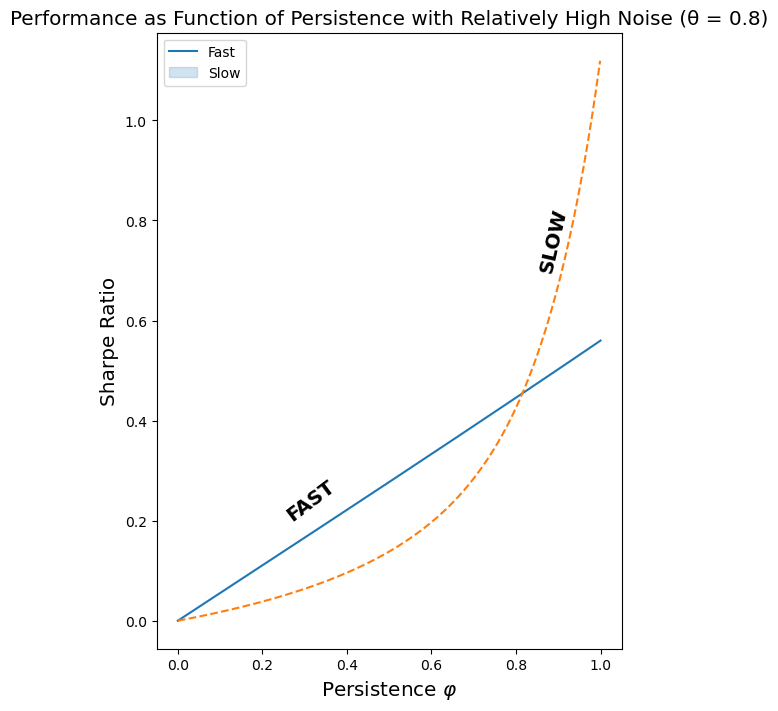

In [20]:
plt.figure(figsize=(6,8))
sns.lineplot(x=psi,y=sharpe_fast)
sns.lineplot(x=psi,y=sharpe_slow,linestyle='--')
plt.plot()
plt.legend(['Fast','Slow'])
plt.xlabel(r'Persistence $\varphi$', fontsize = 'x-large')
plt.ylabel(r'Sharpe Ratio', fontsize = 'x-large')
plt.title('Performance as Function of Persistence with Relatively High Noise (θ = 0.8)', fontsize = 'x-large')
plt.text(.25, .2, 'FAST', fontsize = 'x-large',fontweight='bold', rotation = 37)
plt.text(.85, .7, 'SLOW', fontsize = 'x-large',fontweight='bold', rotation = 77)

<h5> Figure 2(a): Relative Performance as Function of Persistence and Noise

In [22]:
def sharpe_diff_contour(psi, theta):
    return (np.sqrt(24/np.pi)*(1-theta)*psi)/(np.sqrt((((1-theta)*(12*(1-psi**2)-2*psi*(1-psi**12))+12*theta*(1-psi)**2)/((1-psi**12)**2))-(2/np.pi*((1-theta)**2)*psi**2))) - (np.sqrt(24/np.pi)*(1-theta)*psi)/(np.sqrt(1-(2/np.pi*((1-theta)**2)*psi**2))) 

Text(0.85, 0.8, 'FAST')

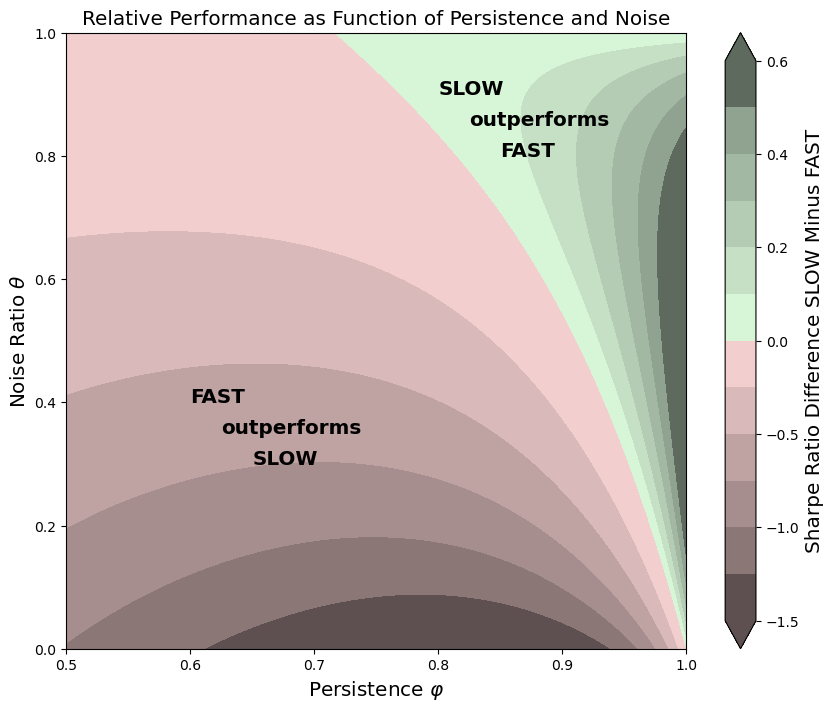

In [23]:
theta = np.linspace(0, 1, 1000)
psi = np.linspace(0.5, 1, 1000)
X, Y = np.meshgrid(psi, theta)
Z = sharpe_diff_contour(X, Y)
fig, ax = plt.subplots()
fig.set_size_inches(10, 8)
plt.contourf(X,Y,Z,levels=[-1.5,-1.25,-1,-.75,-.5,-.25,0,.1,.2,.3,.4,.5,0.6],extend='both'
             ,colors=['#5e5050','#8c7777','#a68e8e','#bfa3a3','#d9b9b9','#f2cece','#d7f5d7','#c5e0c5','#b4ccb4','#a2b8a2','#90a390','#5e6a5e']);
cbar = plt.colorbar();
cbar.ax.set_ylabel('Sharpe Ratio Difference SLOW Minus FAST', rotation=-270, fontsize = 'x-large')
plt.xlabel(r'Persistence $\varphi$', fontsize = 'x-large')
plt.ylabel(r'Noise Ratio $\theta$', fontsize = 'x-large')
plt.title('Relative Performance as Function of Persistence and Noise', fontsize = 'x-large')
plt.text(.6, .4, 'FAST', fontsize = 'x-large',fontweight='bold', rotation = 0)
plt.text(.625, .35, 'outperforms', fontsize = 'x-large',fontweight='bold', rotation = 0)
plt.text(.65, .3, 'SLOW', fontsize = 'x-large',fontweight='bold', rotation = 0)
plt.text(.8, .9, 'SLOW', fontsize = 'x-large',fontweight='bold', rotation = 0)
plt.text(.825, .85, 'outperforms', fontsize = 'x-large',fontweight='bold', rotation = 0)
plt.text(.85, .8, 'FAST', fontsize = 'x-large',fontweight='bold', rotation = 0)

### 2.2.1 Model Turning Points

### 2.3 Characterizing intermeidate speeds and market cycles

$w_t(a) := (1-a)w_{SLOW, t} + a w_{FAST, t}$

$r_{t+1}(a) := w_t (a) r_{t+1} = (1-a)r_{SLOW, t+1} + a r_{FAST, t+1}$

$w_{MED,t} := w_t (\frac{1}{2}) = \frac{1}{2} w_{SLOW} + \frac{1}{2}w_{FAST, t}$